## Imports

In [499]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

## Set Seed

In [500]:
SEED = 42

## Load Data

In [501]:
RAW_DATA_PATH = os.path.normpath(os.path.join("..", "data", "raw"))
raw_data = pd.read_csv(os.path.join(RAW_DATA_PATH, "reddit_twitter_depression_raw.csv"))

In [502]:
raw_data.head(5)

,text,label
0,"He said he had not felt that way before, sugge...",mild
1,"Hey there r/assistance, Not sure if this is th...",minimum
2,My mom then hit me with the newspaper and it s...,minimum
3,"until i met my new boyfriend, he is amazing, h...",mild
4,October is Domestic Violence Awareness Month a...,moderate


In [503]:
raw_data.shape

(41873, 2)

## Checking the Data

### Check for Missing Values

In [504]:
raw_data.isna().sum()

text     14
label     0
dtype: int64

In [505]:
raw_data[raw_data.isna().any(axis=1)]

,text,label
34368,NaN,moderate
35032,NaN,moderate
35063,NaN,moderate
35065,NaN,moderate
35192,NaN,moderate
35741,NaN,moderate
35835,NaN,moderate
37450,NaN,minimum
38114,NaN,minimum
38145,NaN,minimum


In [506]:
raw_data_no_nans = raw_data.dropna()

### Check Text Length

#### Visualise Distributions of Text Length

In [507]:
def plot_answer_lengths(df):
    df = df.copy(deep=True)
    df["text_length"] = df["text"].apply(lambda text: len(text.split()))

    plt.figure(figsize=(15, 10))

    sns.histplot(
        data=df,
        x="text_length",
        bins=70
    )

    plt.title("Histogram of Text Length")
    plt.xlabel("Text Length")
    plt.show()

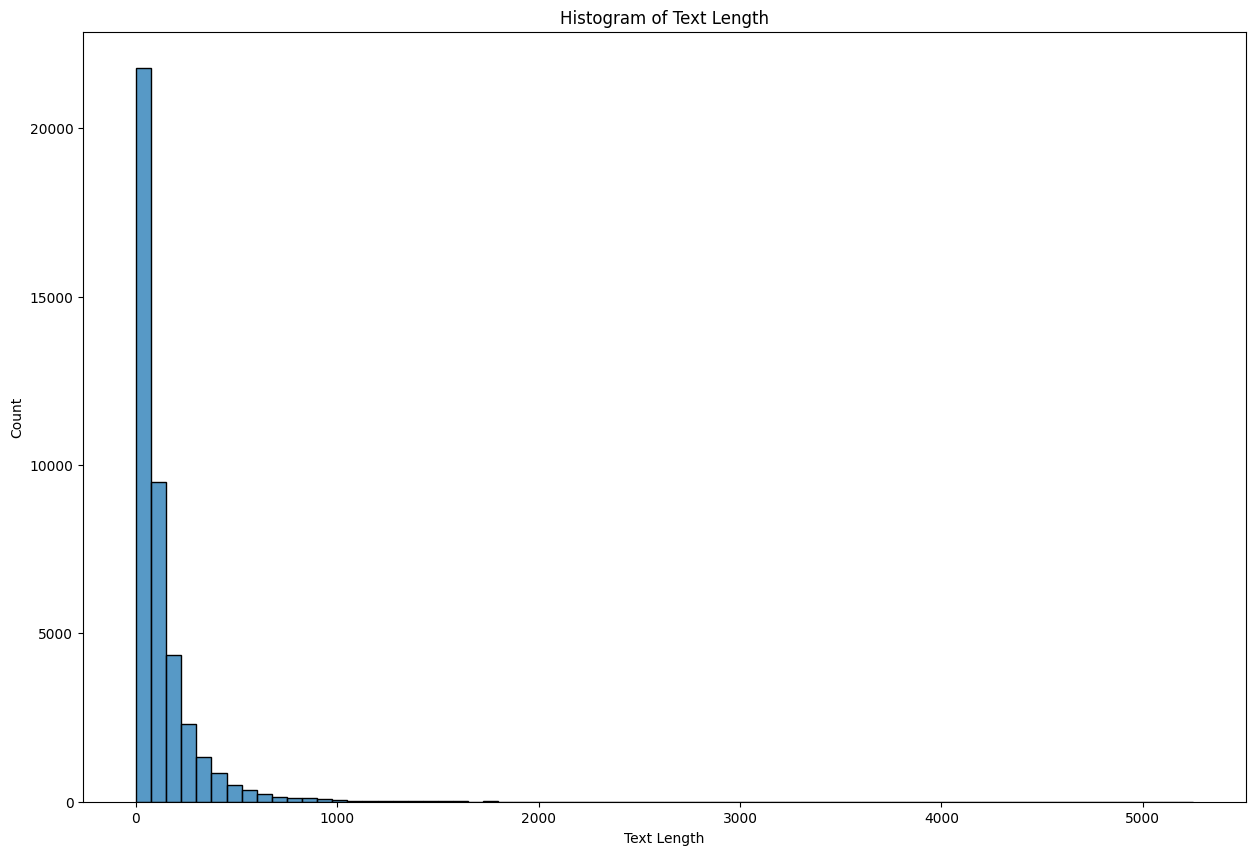

In [508]:
plot_answer_lengths(raw_data_no_nans)

#### Check for Abnormally Short Texts

We are to remove rows corresponding to abnormally short texts - the amount of meaningful information contained within these texts is insufficient.

In [509]:
def find_short_texts(df, min_text_length):
    df = df.copy(deep=True)
    df["text_length"] = df["text"].apply(lambda x: len(x.split()))
    df_short_texts = df[df["text_length"] < min_text_length]
    return df_short_texts.drop(["text_length"], axis=1)

In [510]:
MIN_TEXT_LENGTH = 5       # In terms of approximate number of words (separated by spaces)

In [511]:
find_short_texts(df=raw_data_no_nans, min_text_length=MIN_TEXT_LENGTH)

,text,label
295,#NAME?,minimum
1592,#NAME?,minimum
2190,#NAME?,minimum
2563,#NAME?,minimum
5763,Venting : [removed],moderate
...,...,...
41749,Me: Anxiety: ...unless?,minimum
41757,💕💕💕,minimum
41772,Actually genius.,minimum
41776,Oh https://t.co/Fmh4GEFdSp,minimum


### Find Duplicates

In [512]:
# Returns all rows that have at least one exact duplicate in "text" column
raw_data_no_nans[raw_data_no_nans.duplicated(subset=["text"], keep=False)]

,text,label
170,7. This study will include only participants w...,minimum
295,#NAME?,minimum
419,If you have a survey you would like to share w...,minimum
466,"Hello, You are invited to complete a survey fo...",minimum
521,Can you contribute your story alongside others...,minimum
...,...,...
41358,"When leaders care less about their people, the...",minimum
41362,Intelligence uses what is known to solve probl...,minimum
41544,😍😍😍,minimum
41630,Fuck chess,minimum


### Data Cleaning

In [513]:
def clean_df(df, min_text_length):
    df = df.copy(deep=True)

    # Remove short texts
    df["text_length"] = df["text"].apply(lambda text: len(text.split()))
    df = df[df["text_length"] >= min_text_length]

    # Remove duplicated rows
    df = df.drop_duplicates(subset=["text"])

    # Map label to an integer score
    word_label_to_score = {
        "minimum": 0,
        "mild": 1,
        "moderate": 2,
        "severe": 3
    }
    df["label"] = df["label"].apply(lambda word_label: word_label_to_score[word_label])

    # Rename columns to suit default column names accepted by Hugging Face
    df = df.rename(columns={"label": "labels"})

    # Drop columns
    df = df.drop(["text_length"], axis=1)

    return df

In [514]:
cleaned_data = clean_df(df=raw_data_no_nans, min_text_length=MIN_TEXT_LENGTH)

In [515]:
cleaned_data.head(5)

,text,labels
0,"He said he had not felt that way before, sugge...",1
1,"Hey there r/assistance, Not sure if this is th...",0
2,My mom then hit me with the newspaper and it s...,0
3,"until i met my new boyfriend, he is amazing, h...",1
4,October is Domestic Violence Awareness Month a...,2


In [516]:
cleaned_data.shape

(31786, 2)

## Split Data

In [517]:
cleaned_data_label_counts = cleaned_data["labels"].value_counts()

In [518]:
cleaned_data_label_counts

labels
3    10647
1    10642
0     6141
2     4356
Name: count, dtype: int64

In [519]:
# Conduct undersampling
min_count_for_undersampling = cleaned_data_label_counts.min()

# Undersample all classes to this size
cleaned_balanced_data = cleaned_data \
    .groupby("labels") \
    .sample(n=min_count_for_undersampling, random_state=SEED) \
    .reset_index(drop=True)


In [520]:
cleaned_balanced_data["labels"].value_counts()

labels
0    4356
1    4356
2    4356
3    4356
Name: count, dtype: int64

In [521]:
TRAIN_SIZE = 0.8
TEST_SIZE = 0.1

In [522]:
# Get features and labels
X, y = cleaned_balanced_data.drop(["labels"], axis=1), cleaned_balanced_data["labels"]

# Split train from val and test
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X, y, train_size=TRAIN_SIZE, stratify=y, random_state=SEED
)

# Split val and test
test_size_wrt_remaining = TEST_SIZE / (1 - TRAIN_SIZE)
X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test, test_size=test_size_wrt_remaining, stratify=y_val_test, random_state=SEED
)

# Obtain final train and test data frames
train_df = pd.concat([X_train, y_train], axis=1)
val_df = pd.concat([X_val, y_val], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

## Value Counts of Splits

In [523]:
def plot_value_counts(df):
    level_counts = df["labels"].value_counts().reset_index().sort_values("labels")

    # Plot bar chart
    plt.figure(figsize=(12, 6))
    sns.barplot(data=level_counts, x="labels", y="count", hue="labels",
                palette="viridis", legend=False)
    
    for _, row in level_counts.iterrows():
        plt.text(row["labels"], row["count"] + 10, f"{row['count']}", ha="center", va="bottom",
                fontsize=10, fontweight="bold")

    plt.title("Severity Label Counts in Reddit & Twitter Dataset", fontsize=13, fontweight="bold")
    plt.xlabel("Severity Label", fontsize=11, fontweight="bold")
    plt.ylabel("Number of Text Samples", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

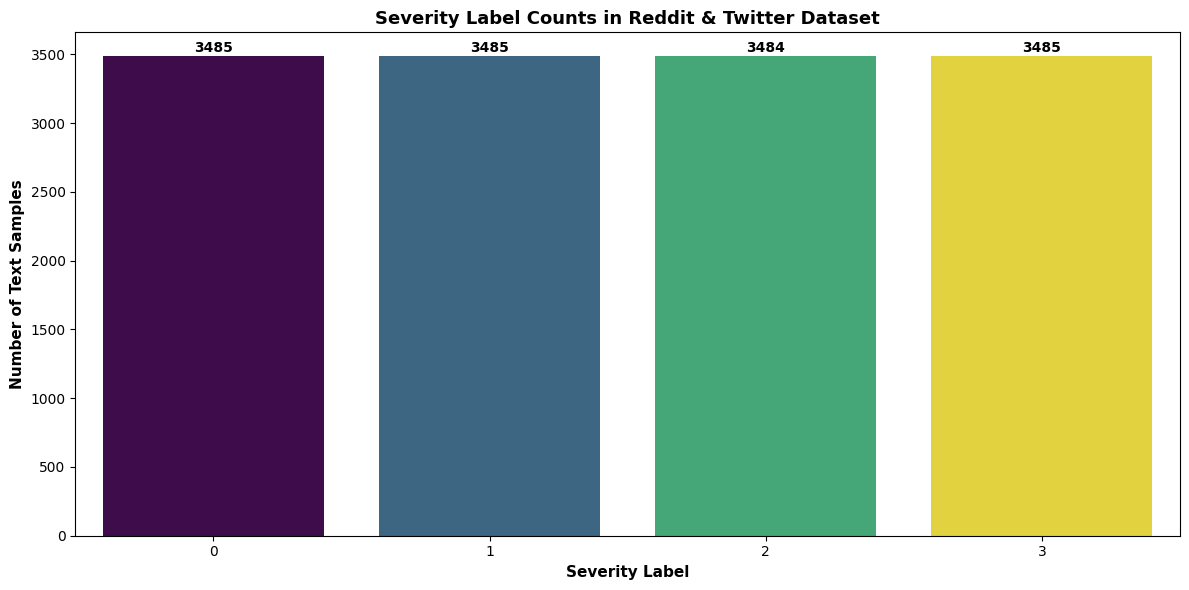

In [524]:
plot_value_counts(df=train_df)

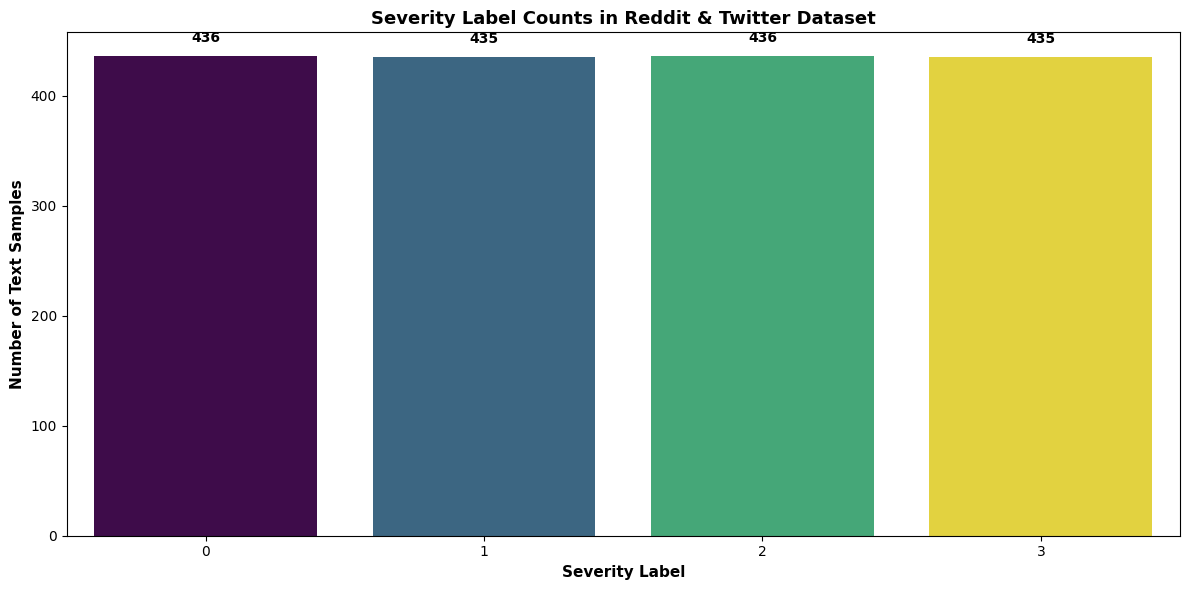

In [525]:
plot_value_counts(df=val_df)

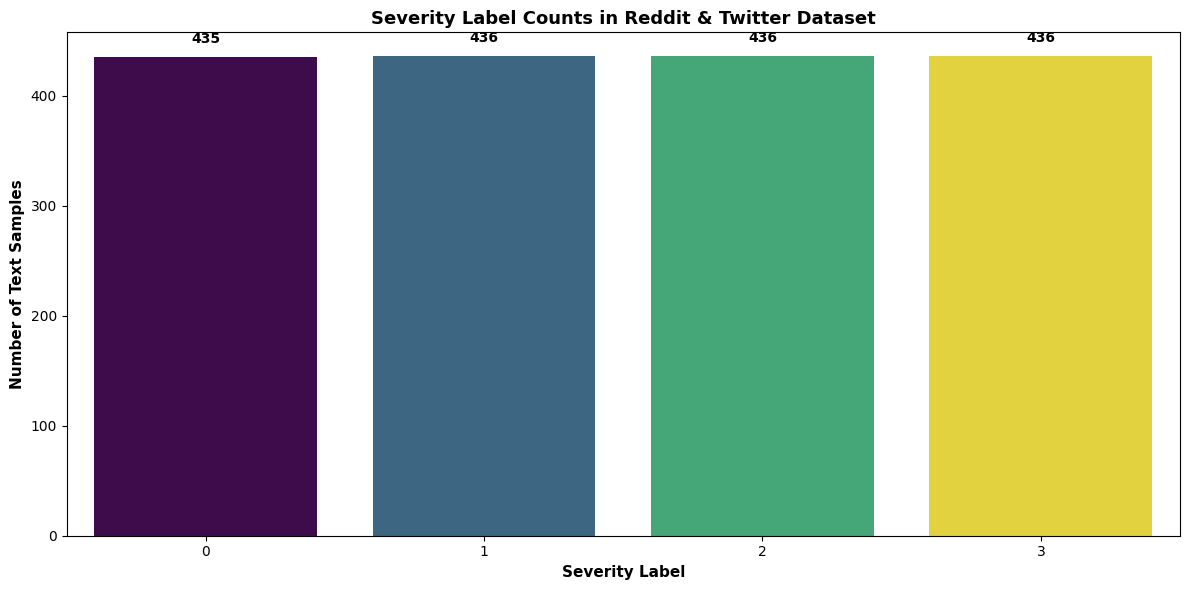

In [526]:
plot_value_counts(df=test_df)

## Save Data

In [527]:
PROCESSED_DATA_PATH = os.path.normpath(os.path.join("..", "data", "processed"))
os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)
train_df.to_csv(os.path.join(PROCESSED_DATA_PATH, "train.csv"), index=False)
val_df.to_csv(os.path.join(PROCESSED_DATA_PATH, "val.csv"), index=False)
test_df.to_csv(os.path.join(PROCESSED_DATA_PATH, "test.csv"), index=False)